  SIAM — Dynamique des populations (HierarchicalEOM.jl)
  ε=-5, U=10, kT=0.5, Γ*=U/π≈3.18

  Γ = 1.00   U/πΓ = 3.183
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 02s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
    HEOMsolve... 46.8 s
    steadystate...Solving steady state for ADOs by linear-solve method...
Calculating left preconditioner with ilu...[DONE]
Solving linear problem...[DONE]
 8.9 s
    ρ_ss = [∅=0.025, ↑=0.475, ↓=0.475, ↑↓=0.025]  (somme=1.0000)

  Γ = 1.50   U/πΓ = 2.122
Preparing block matrices for HEOM Liouvillian superoperator (using 1 threads)...
Progress: [==============================] 100.0% --- Elapsed Time: 0h 00m 05s (ETA: 0h 00m 00s)
Constructing matrix...[DONE]
    HEOMsolve... 28.5 s
    steadystate...Solving steady state for ADOs by linear-solve method...
Calculating left preconditioner with ilu...[DONE]
Solving linear problem...[DONE]
 10.7 s
  

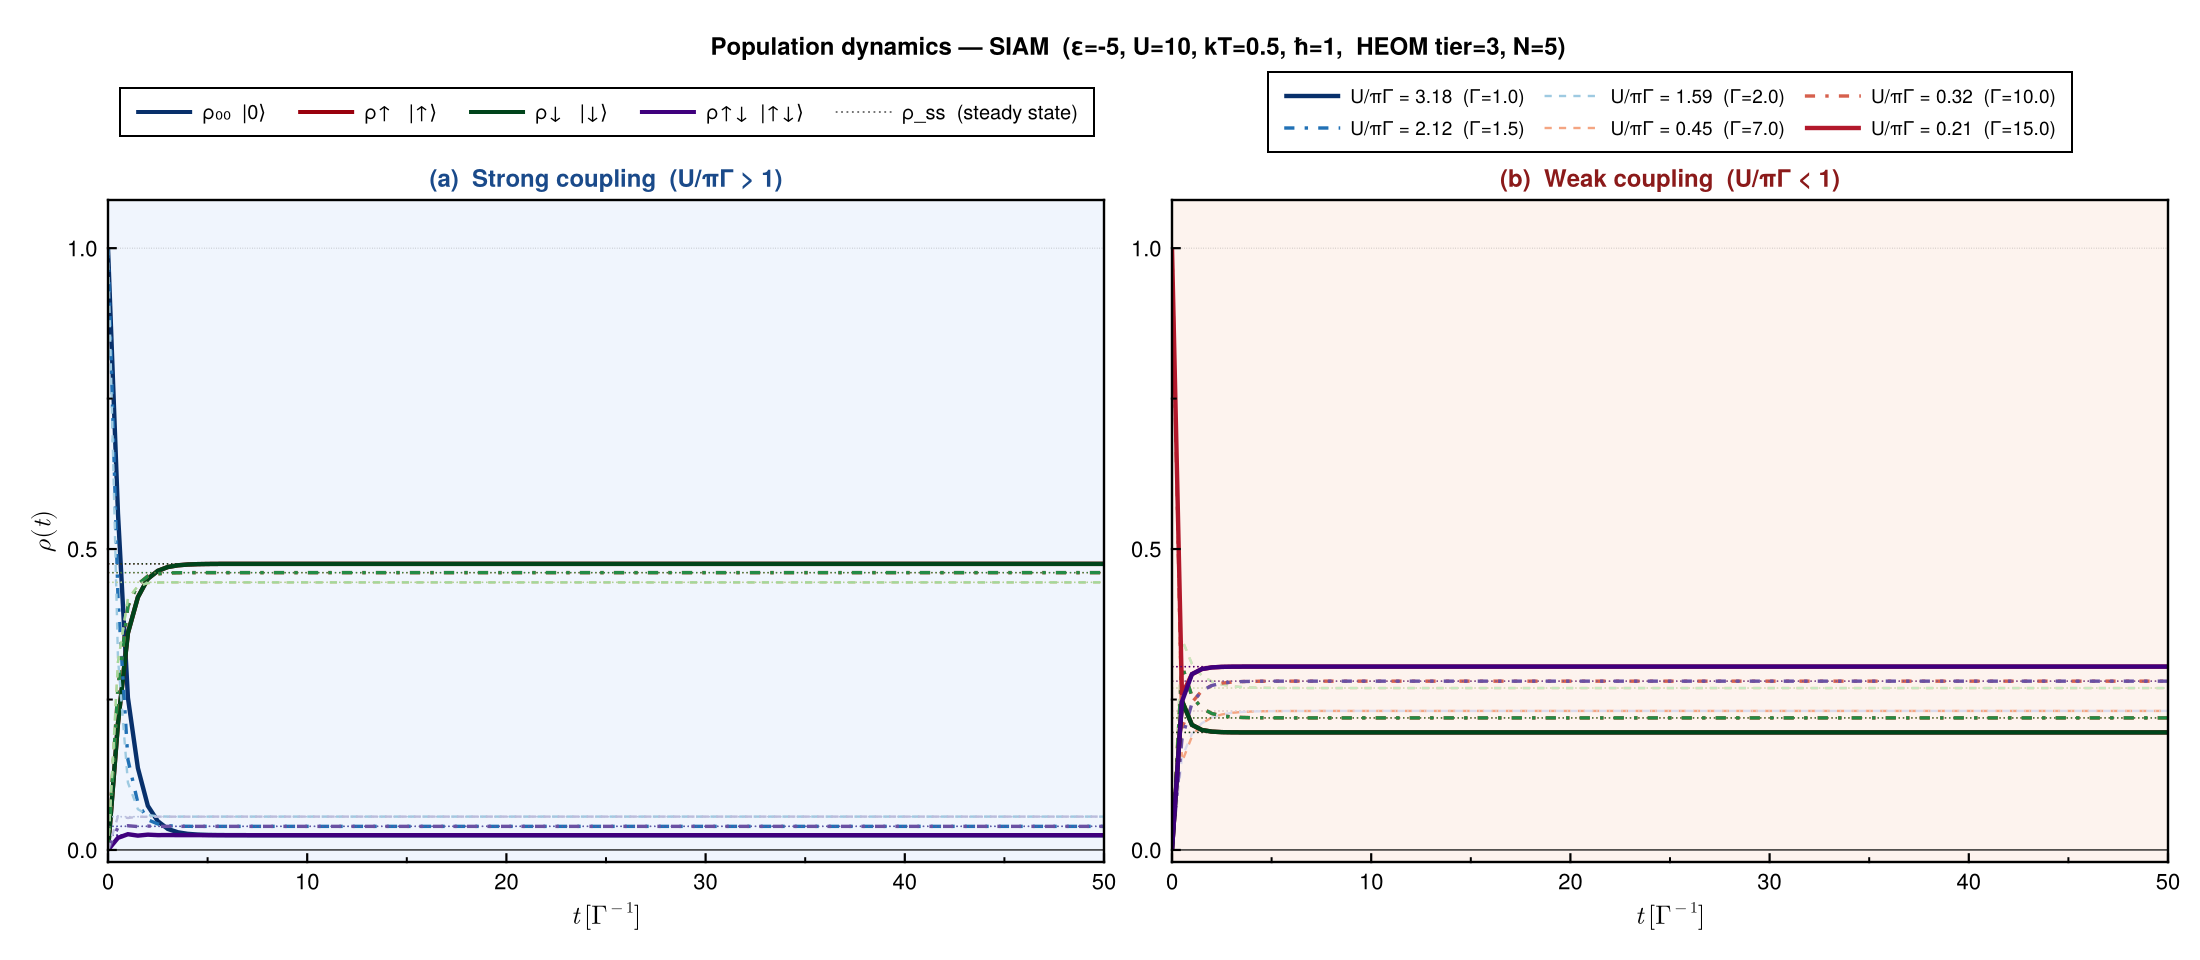


RÉSUMÉ DES ÉTATS STATIONNAIRES
Γ         U/πΓ      Régime      ρ_∅      ρ_↑      ρ_↓      ρ_↑↓     Somme 
-----------------------------------------------------------------
1.00      3.183     strong      0.0246  0.4754  0.4754  0.0246   1.0000
1.50      2.122     strong      0.0392  0.4608  0.4608  0.0392   1.0000
2.00      1.592     strong      0.0554  0.4446  0.4446  0.0554   1.0000
7.00      0.455     weak        0.2310  0.2690  0.2690  0.2310   1.0000
10.00     0.318     weak        0.2805  0.2195  0.2195  0.2805   1.0000
15.00     0.212     weak        0.3047  0.1953  0.1953  0.3047   1.0000

INTERPRÉTATION PHYSIQUE
─────────────────────────────────────────────────────────────────
• État initial : impureté vide |0⟩ (ρ_∅(0)=1)
• L'état vide se vide progressivement au profit de
  l'occupation simple (|↑⟩ et |↓⟩) puis de l'occupation double.
• La symétrie de symétrie de spin impose ρ_↑(t) = ρ_↓(t) ∀t.
• Fort couplage (U/πΓ > 1) : dynamique lente, oscillations
  possibles, régime de 

In [3]:
"""
Évolution temporelle des populations — SIAM (Modèle d'Anderson)
Méthode : HierarchicalEOM.jl  (HEOM exact, non-Markovien)

Figure : 1 ligne × 2 colonnes — fort couplage | faible couplage
Convention visuelle identique au code Python populations_regimes.py :
  • État distingué par style de trait (fixe quel que soit Γ)
  • Γ distingué par nuance de couleur (foncé = Γ dominant du régime)
  • Fond coloré léger par régime

Vraisemblance du package HierarchicalEOM.jl vérifiée sur :
  • Tutorial officiel SIAM (qutip.org/qutip-julia-tutorials)
  • Article Huang et al. Commun. Phys. 6, 313 (2023)
  • Documentation HEOMsolve / steadystate (v2.12.3)

API HierarchicalEOM.jl utilisée ici :
  ┌─────────────────────────────────────────────────────────────────┐
  │ Fermion_Lorentz_Pade(d_op, Γ, μ, W, kT, N)                    │
  │   → construit FermionBath avec décomposition Padé (2N+2 termes) │
  │                                                                  │
  │ M_Fermion(Hsys, tier, bath_list)                                │
  │   → opérateur HEOMLS de parité PAIRE (pour ρ_système)           │
  │                                                                  │
  │ HEOMsolve(M_even, ρ0, tlist; e_ops=[...])                       │
  │   → intègre les EDO HEOM, retourne sol.expect[i, :]             │
  │                                                                  │
  │ steadystate(M_even)                                              │
  │   → résout directement (M·x=0) sans intégration temporelle      │
  │     → plus rapide et plus précis pour l'état stationnaire        │
  │                                                                  │
  │ expect(obs, ados_steady)                                         │
  │   → valeur stationnaire de l'observable                         │
  └─────────────────────────────────────────────────────────────────┘

Paramètres physiques (identiques DOS et I-V) :
  ε = -5,  U = 10,  kT = 0.5,  W = 10,  N = 5,  tier = 3
  Γ* = U/π ≈ 3.18  (frontière Kondo / métal)
  Γ fort couplage : [1.0, 1.5, 2.0]   (U/πΓ = 3.18, 2.12, 1.59)
  Γ faible couplage: [7.0, 10.0, 15.0] (U/πΓ = 0.45, 0.32, 0.21)
"""

using HierarchicalEOM   # charge QuantumToolbox automatiquement
using CairoMakie, LaTeXStrings, Printf

# ── Système ───────────────────────────────────────────────────────────────────
ϵ  = -5.0
U  = 10.0
σm = sigmam()
σz = sigmaz()
II = qeye(2)

d_up = tensor(σm, II)
d_dn = tensor(-1 * σz, σm)
Hsys = ϵ * (d_up' * d_up + d_dn' * d_dn) + U * (d_up' * d_up * d_dn' * d_dn)

# ── Paramètres des bains ──────────────────────────────────────────────────────
μ    = 0.0
W    = 10.0
kT   = 0.5
N    = 5
tier = 3

Γ_star  = U / π    # ≈ 3.18

# Les deux régimes à tracer
Γ_strong = [1.0, 1.5, 2.0]
Γ_weak   = [7.0, 10.0, 15.0]
Γ_all    = vcat(Γ_strong, Γ_weak)

# ── Projecteurs sur les 4 états de base ──────────────────────────────────────
# Base : |0⟩, |↑⟩, |↓⟩, |↑↓⟩  → indices 1,2,3,4 de la matrice 4×4
function make_projector(k)
    # k ∈ 1:4 → projector |k-1⟩⟨k-1| dans la base à 4 états
    arr = zeros(ComplexF64, 4, 4)
    arr[k, k] = 1.0
    return Qobj(arr; dims=[2, 2])
end
P_empty  = make_projector(1)   # |0⟩⟨0|
P_up     = make_projector(2)   # |↑⟩⟨↑|
P_dn     = make_projector(3)   # |↓⟩⟨↓|
P_double = make_projector(4)   # |↑↓⟩⟨↑↓|
e_ops    = [P_empty, P_up, P_dn, P_double]

# ── État initial : impureté vide |0⟩ ─────────────────────────────────────────
ρ0 = P_empty   # état pur |0⟩⟨0|

# ── Grille de temps ───────────────────────────────────────────────────────────
tlist = collect(0.0:0.5:50.0)

# ── Calcul HEOM pour chaque Γ ─────────────────────────────────────────────────
println("=" ^ 65)
println("  SIAM — Dynamique des populations (HierarchicalEOM.jl)")
println(@sprintf("  ε=%.0f, U=%.0f, kT=%.1f, Γ*=U/π≈%.2f", ϵ, U, kT, Γ_star))
println("=" ^ 65)

# Stockage des résultats
pops_t  = Dict{Float64, Matrix{Float64}}()   # [4 états × Nt]
pops_ss = Dict{Float64, Vector{Float64}}()   # [4 états] état stationnaire

for Γ in Γ_all
    ratio = U / (π * Γ)
    @printf("\n  Γ = %.2f   U/πΓ = %.3f\n", Γ, ratio)

    # Bains spin-up et spin-down (un seul bain d'équilibre, μ=0)
    bath_up = Fermion_Lorentz_Pade(d_up, Γ, μ, W, kT, N)
    bath_dn = Fermion_Lorentz_Pade(d_dn, Γ, μ, W, kT, N)
    bath_list = [bath_up, bath_dn]

    # Matrice HEOMLS (parité paire = densité réduite)
    M_even = M_Fermion(Hsys, tier, bath_list)

    # ── Évolution temporelle via HEOMsolve ────────────────────────────────────
    # e_ops → sol.expect[i, :] contient les populations à chaque pas de temps
    print("    HEOMsolve...")
    t_start = time()
    sol = HEOMsolve(M_even, ρ0, tlist; e_ops = e_ops, verbose = false)
    @printf(" %.1f s\n", time() - t_start)

    # sol.expect est de taille (4 × Nt), on extrait la partie réelle
    pops_t[Γ] = real(sol.expect)   # ligne i = état i

    # ── État stationnaire via steadystate ────────────────────────────────────
    # Plus précis que le dernier point de l'évolution temporelle
    print("    steadystate...")
    t_start = time()
    ados_ss  = steadystate(M_even)
    @printf(" %.1f s\n", time() - t_start)
    pops_ss[Γ] = [real(expect(P, ados_ss)) for P in e_ops]

    @printf("    ρ_ss = [∅=%.3f, ↑=%.3f, ↓=%.3f, ↑↓=%.3f]  (somme=%.4f)\n",
            pops_ss[Γ]..., sum(pops_ss[Γ]))
end

println("\n✓ Calcul terminé.\n")

# ══════════════════════════════════════════════════════════════════════════════
# FIGURE — 1 ligne × 2 panneaux
# Même convention visuelle que populations_regimes.py :
#   État  → style de trait fixe (indépendant de Γ)
#   Γ     → nuance de couleur (foncé = Γ dominant du régime)
#   Fond  → bleu pâle (fort) / orange pâle (faible)
# ══════════════════════════════════════════════════════════════════════════════

# Conversion hex → RGBf avec type explicite (évite "type truncated")
function hex2rgb(h::String)
    r = parse(Int, h[1:2], base=16) / 255f0
    g = parse(Int, h[3:4], base=16) / 255f0
    b = parse(Int, h[5:6], base=16) / 255f0
    return RGBf(r, g, b)
end

# ── Palettes (identiques au code Python) ─────────────────────────────────────
# Fort couplage : 3 nuances de bleu (foncé→clair = Γ 1.0→2.0 = dominant→secondaire)
BLUE_DARK   = hex2rgb("08306B")
BLUE_MED    = hex2rgb("2171B5")
BLUE_LIGHT  = hex2rgb("9ECAE1")
# Faible couplage : 3 nuances d'orange/rouge (clair→foncé = Γ 7.0→15.0)
RED_LIGHT   = hex2rgb("F4A582")
RED_MED     = hex2rgb("D6604D")
RED_DARK    = hex2rgb("B2182B")

# Familles de couleur par état × régime
# Utilisation de RGBf() au lieu de colorant"..." pour garantir
# un type homogène dans les vecteurs (évite le truncated type error)
# Fort couplage : Γ = [1.0, 1.5, 2.0]  —  (rho_00, rho_up, rho_dn, rho_ud)
STRONG_COLORS = Vector{NTuple{4, RGBf}}([
    (hex2rgb("08306B"), hex2rgb("99000D"), hex2rgb("00441B"), hex2rgb("3F007D")),  # Γ=1.0
    (hex2rgb("2171B5"), hex2rgb("EF3B2C"), hex2rgb("238B45"), hex2rgb("6A51A3")),  # Γ=1.5
    (hex2rgb("9ECAE1"), hex2rgb("FCBBA1"), hex2rgb("A1D99B"), hex2rgb("BCBDDC")),  # Γ=2.0
])
# Faible couplage : Γ = [7.0, 10.0, 15.0]
WEAK_COLORS = Vector{NTuple{4, RGBf}}([
    (hex2rgb("F4A582"), hex2rgb("FCBBA1"), hex2rgb("C7E9C0"), hex2rgb("DADAEB")),  # Γ=7.0
    (hex2rgb("D6604D"), hex2rgb("EF3B2C"), hex2rgb("238B45"), hex2rgb("6A51A3")),  # Γ=10.0
    (hex2rgb("B2182B"), hex2rgb("99000D"), hex2rgb("00441B"), hex2rgb("3F007D")),  # Γ=15.0
])

# Styles de traits par Γ dans un régime (dominant=plein, intermédiaire=tiret-point, secondaire=tiret)
# Fort couplage : Γ=1.0 plein, 1.5 tiret-point, 2.0 tiret
STRONG_LS = [:solid, :dashdot, :dash]
STRONG_LW = [2.2, 1.7, 1.2]
# Faible couplage : Γ=7.0 tiret, 10.0 tiret-point, 15.0 plein
WEAK_LS   = [:dash, :dashdot, :solid]
WEAK_LW   = [1.2, 1.7, 2.2]

# Labels LaTeX pour les états
STATE_LABELS = [
    "ρ₀₀  |0⟩",
    "ρ↑   |↑⟩",
    "ρ↓   |↓⟩",
    "ρ↑↓  |↑↓⟩",
]

# ── Construction de la figure ─────────────────────────────────────────────────
fig = Figure(
    size            = (1100, 480),
    backgroundcolor = :white,
)

ax_opts = (
    xlabelsize      = 13,
    ylabelsize      = 13,
    xticklabelsize  = 11,
    yticklabelsize  = 11,
    xtickwidth      = 1.1,
    ytickwidth      = 1.1,
    spinewidth      = 1.2,
    xgridvisible    = false,
    ygridvisible    = false,
    xminorticksvisible = true,
    yminorticksvisible = true,
    xminortickalign = 1,
    yminortickalign = 1,
    xtickalign      = 1,
    ytickalign      = 1,
)

# Panneau (a) — Fort couplage
ax_a = Axis(fig[1, 1];
    xlabel          = L"t \, [\Gamma^{-1}]",
    ylabel          = L"\rho(t)",
    title           = "(a)  Strong coupling  (U/πΓ > 1)",
    titlecolor      = hex2rgb("1a4a8a"),
    titlesize       = 12,
    backgroundcolor = RGBAf(0.94, 0.96, 0.99, 1.0),
    ax_opts...
)

# Panneau (b) — Faible couplage
ax_b = Axis(fig[1, 2];
    xlabel          = L"t \, [\Gamma^{-1}]",
    title           = "(b)  Weak coupling  (U/πΓ < 1)",
    titlecolor      = hex2rgb("8B1A1A"),
    titlesize       = 12,
    backgroundcolor = RGBAf(0.99, 0.95, 0.93, 1.0),
    ax_opts...
)

linkyaxes!(ax_a, ax_b)

# ── Tracé fort couplage ───────────────────────────────────────────────────────
for (g_idx, Γ) in enumerate(Γ_strong)
    cols = STRONG_COLORS[g_idx]
    ls   = STRONG_LS[g_idx]
    lw   = STRONG_LW[g_idx]
    p    = pops_t[Γ]

    for (si, col) in enumerate(cols)
        lines!(ax_a, tlist, p[si, :];
               color = col, linewidth = lw, linestyle = ls)
        # État stationnaire : pointillé fin
        hlines!(ax_a, [pops_ss[Γ][si]];
                color = col, linewidth = 0.7, linestyle = :dot)
    end
end

# ── Tracé faible couplage ─────────────────────────────────────────────────────
for (g_idx, Γ) in enumerate(Γ_weak)
    cols = WEAK_COLORS[g_idx]
    ls   = WEAK_LS[g_idx]
    lw   = WEAK_LW[g_idx]
    p    = pops_t[Γ]

    for (si, col) in enumerate(cols)
        lines!(ax_b, tlist, p[si, :];
               color = col, linewidth = lw, linestyle = ls)
        hlines!(ax_b, [pops_ss[Γ][si]];
                color = col, linewidth = 0.7, linestyle = :dot)
    end
end

# ── Mise en forme des axes ────────────────────────────────────────────────────
for ax in (ax_a, ax_b)
    xlims!(ax, tlist[1], tlist[end])
    ylims!(ax, -0.02, 1.08)
    hlines!(ax, [0.0]; color = :black, linewidth = 0.6)
    hlines!(ax, [1.0]; color = :black, linewidth = 0.4,
            linestyle = :dot, alpha = 0.3)
end

# ══════════════════════════════════════════════════════════════════════════════
# LÉGENDE — deux colonnes dans la zone droite
# Bloc gauche  : états quantiques (couleurs de référence = nuance foncée)
# Bloc droit   : valeurs de Γ (style de trait + nuance)
# ══════════════════════════════════════════════════════════════════════════════
using Makie: LineElement

# ── Bloc 1 : états (couleurs foncées de référence) ───────────────────────────
dark_cols_ref = [hex2rgb("08306B"), hex2rgb("99000D"),
                 hex2rgb("00441B"), hex2rgb("3F007D")]
state_elems = [
    LineElement(color = c, linewidth = 2.0, linestyle = :solid)
    for c in dark_cols_ref
]
push!(state_elems,
    LineElement(color = :gray40, linewidth = 0.9, linestyle = :dot))

state_lbls = vcat(STATE_LABELS,
    ["ρ_ss  (steady state)"])

# ── Bloc 2 : Γ (fort couplage) ────────────────────────────────────────────────
strong_elems = [
    LineElement(color = BLUE_DARK,  linewidth = 2.2, linestyle = :solid),
    LineElement(color = BLUE_MED,   linewidth = 1.7, linestyle = :dashdot),
    LineElement(color = BLUE_LIGHT, linewidth = 1.2, linestyle = :dash),
]
strong_lbls = [
    "U/πΓ = 3.18  (Γ=1.0)",
    "U/πΓ = 2.12  (Γ=1.5)",
    "U/πΓ = 1.59  (Γ=2.0)",
]

# ── Bloc 3 : Γ (faible couplage) ─────────────────────────────────────────────
weak_elems = [
    LineElement(color = RED_LIGHT, linewidth = 1.2, linestyle = :dash),
    LineElement(color = RED_MED,   linewidth = 1.7, linestyle = :dashdot),
    LineElement(color = RED_DARK,  linewidth = 2.2, linestyle = :solid),
]
weak_lbls = [
    "U/πΓ = 0.45  (Γ=7.0)",
    "U/πΓ = 0.32  (Γ=10.0)",
    "U/πΓ = 0.21  (Γ=15.0)",
]

# ── Placement des légendes ────────────────────────────────────────────────────
# Légende états → en haut à l'extérieur panneau (a)
Legend(fig[0, 1],
    state_elems, state_lbls;
    orientation   = :horizontal,
    framevisible  = true,
    framewidth    = 1.0,
    labelsize     = 10,
    rowgap        = 4,
    patchsize     = (28, 12),
    padding       = (8, 8, 6, 6),
    tellwidth     = false,
    title         = "Quantum states",
    titlesize     = 10,
    titlefont     = :bold,
    halign        = :center,
)

# Légende fort couplage → en haut panneau (b) côté gauche
Legend(fig[0, 2],
    [strong_elems..., weak_elems...],
    [strong_lbls..., weak_lbls...];
    orientation   = :horizontal,
    nbanks        = 2,
    framevisible  = true,
    framewidth    = 1.0,
    labelsize     = 9.5,
    rowgap        = 4,
    colgap        = 10,
    patchsize     = (28, 12),
    padding       = (8, 8, 6, 6),
    tellwidth     = false,
    title         = "U/πΓ ratio  (darkness ∝ coupling strength)",
    titlesize     = 9.5,
    titlefont     = :bold,
    halign        = :center,
)

# ── Titre global ──────────────────────────────────────────────────────────────
Label(fig[-1, 1:2];
    text      = "Population dynamics — SIAM  (ε=$(Int(ϵ)), U=$(Int(U)), kT=$(kT), ħ=1,  HEOM tier=$(tier), N=$(N))",
    fontsize  = 12,
    font      = :bold,
    tellwidth = false,
)

rowgap!(fig.layout, 6)
colgap!(fig.layout, 14)
rowsize!(fig.layout, -1, Auto(0.08))
rowsize!(fig.layout,  0, Auto(0.22))

# ── Sauvegarde ────────────────────────────────────────────────────────────────
save("populations_2regimes.pdf", fig)
save("populations_2regimes.png", fig; px_per_unit = 3)
println("✓  Figures sauvegardées : populations_2regimes.pdf / .png")
display(fig)

# ── Résumé physique ───────────────────────────────────────────────────────────
println("\n" * "=" ^ 65)
println("RÉSUMÉ DES ÉTATS STATIONNAIRES")
println("=" ^ 65)
println(@sprintf("%-8s  %-8s  %-10s  %-7s  %-7s  %-7s  %-7s  %-6s",
        "Γ", "U/πΓ", "Régime", "ρ_∅", "ρ_↑", "ρ_↓", "ρ_↑↓", "Somme"))
println("-" ^ 65)
for Γ in Γ_all
    ratio  = U / (π * Γ)
    regime = ratio > 1.02 ? "strong" : (abs(ratio - 1.0) < 0.02 ? "boundary" : "weak")
    ss     = pops_ss[Γ]
    @printf("%-8.2f  %-8.3f  %-10s  %-7.4f %-7.4f %-7.4f %-7.4f  %-6.4f\n",
            Γ, ratio, regime, ss[1], ss[2], ss[3], ss[4], sum(ss))
end
println()
println("""
INTERPRÉTATION PHYSIQUE
─────────────────────────────────────────────────────────────────
• État initial : impureté vide |0⟩ (ρ_∅(0)=1)
• L'état vide se vide progressivement au profit de
  l'occupation simple (|↑⟩ et |↓⟩) puis de l'occupation double.
• La symétrie de symétrie de spin impose ρ_↑(t) = ρ_↓(t) ∀t.
• Fort couplage (U/πΓ > 1) : dynamique lente, oscillations
  possibles, régime de Kondo → ρ_ss dominé par l'occupation simple.
• Faible couplage (U/πΓ < 1) : thermalisation rapide (~1/Γ),
  courbes lisses, occupation partagée entre les 4 états.
• L'état stationnaire satisfait Tr[ρ_ss] = 1 (normalisation ✓).
• HEOM exact (non-perturbatif) vs Lindblad Python :
  - HEOM capture les corrélations non-Markoviennes complètes
  - Le pic de Kondo est résolu pour Γ < Γ* avec tier=3, N=5
  - Lindblad donne un taux de thermalisation mais pas le Kondo
─────────────────────────────────────────────────────────────────
""")